In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim

plt.style.use('ggplot')
%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
t = torch.linspace(0, 5, 500)

Аналитическое решение

In [ ]:
x_analitical = 0.5 * np.exp(-t) + 0.5 * np.exp(-3 * t)
y_analitical = - 0.5 * np.exp(-t) + 0.5 * np.exp(-3 * t)

/tmp/ipykernel_456/3803342663.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  x_analitical = 0.5 * np.exp(-t) + 0.5 * np.exp(-3 * t)
/tmp/ipykernel_456/3803342663.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_analitical = - 0.5 * np.exp(-t) + 0.5 * np.exp(-3 * t)


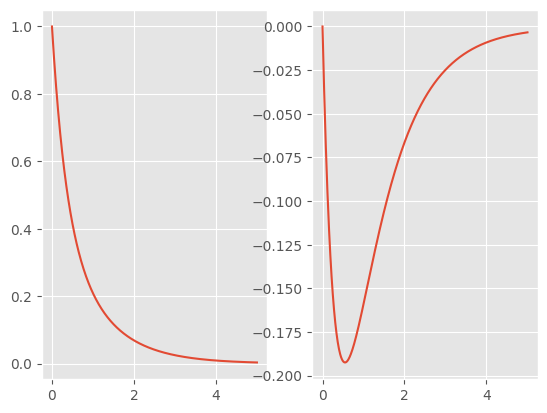

In [ ]:
plt.subplot(1, 2, 1)
plt.plot(t, x_analitical)
plt.subplot(1, 2, 2)
plt.plot(t, y_analitical)
plt.show()

In [ ]:
#simple
class SimplePinn(nn.Module):
    def __init__(self):
        super().__init__()

        activation = nn.Tanh()

        self.first_layer = nn.Sequential(nn.Linear(1, 64),
                                         activation)
        self.hidden_layer1 = nn.Sequential(nn.Linear(64, 64),
                                         activation)
        self.hidden_layer2 = nn.Sequential(nn.Linear(64, 64),
                                         activation)
        self.last_layer = nn.Sequential(nn.Linear(64, 2))

    def forward(self, x):
        x = self.first_layer(x)
        x = self.hidden_layer1(x)
        x = self.hidden_layer2(x)
        x = self.last_layer(x)

        return x

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, width, activation):
        super().__init__()
        self.fc1 = nn.Linear(width, width)
        self.activation = activation

    def forward(self, x):
        return self.activation(x + self.activation(self.fc1(x)))


class PINN(nn.Module):
    def __init__(self, dim_hidden, num_layers=4):
        super().__init__()

        activation1 = nn.Tanh()

        self.hidden_layer = nn.Sequential(*[ResidualBlock(dim_hidden, activation1)
                                                for _ in range(num_layers)])

        self.first_layer = nn.Sequential(nn.Linear(2, dim_hidden),
                                         activation1)

        self.last_layer = nn.Sequential(nn.Linear(dim_hidden, 1))

    def forward(self, x):
        out = torch.cat([torch.sin(x), torch.cos(x)], dim=1)

        out = self.first_layer(out)
        out = self.hidden_layer(out)
        out = self.last_layer(out)

        return out

In [ ]:
def loss_fn(model, t):
    output = model(t)
    x = output[:, 0:1]
    y = output[:, 1:2]

    dx_dt = torch.autograd.grad(
    outputs=x,
    inputs=t,
    grad_outputs=torch.ones_like(x),
    create_graph=True)[0]

    dy_dt = torch.autograd.grad(
    outputs=y,
    inputs=t,
    grad_outputs=torch.ones_like(y),
    create_graph=True)[0]

    res_x = dx_dt + 2*x + y
    res_y = dy_dt + x + 2*y

    init_loss_x = torch.square(x[0] - 1)
    init_loss_y = torch.square(y[0])

    loss = torch.mean(torch.square(res_x)) + torch.mean(torch.square(res_y)) + init_loss_x + init_loss_y
    return loss

In [ ]:
def train(model, t, epochs, optimizer):
    for epoch in range(1, epochs+1):
        loss = loss_fn(model, t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 500 == 0:
            print(f'Epoch: {epoch}, loss: {loss.item()}')

In [ ]:
pinn = SimplePinn()
optimizer = torch.optim.Adam(pinn.parameters(), lr=0.001)

In [ ]:
t_points = torch.tensor(t[:, None])
t_points.requires_grad_(True);

/tmp/ipykernel_456/3543813239.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_points = torch.tensor(t[:, None])


In [ ]:
train(pinn, t_points, 5000, optimizer)

Epoch: 0, loss: 0.9968921542167664
Epoch: 500, loss: 0.0049037085846066475
Epoch: 1000, loss: 1.1776531209761743e-05
Epoch: 1500, loss: 1.1140135939058382e-05
Epoch: 2000, loss: 7.294893748621689e-06
Epoch: 2500, loss: 4.76314426123281e-06
Epoch: 3000, loss: 3.0038247587071965e-06
Epoch: 3500, loss: 1.874145141300687e-06
Epoch: 4000, loss: 1.2437845953172655e-06
Epoch: 4500, loss: 1.6667171394146862e-06
